In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **Importing Libraries**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
data=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

#  **EXPLORARTORY DATA ANALYSIS**

#### Checking dimesion of train and test dataset

In [36]:
print(data.shape)
print(test.shape)

(198000, 15)
(102000, 14)


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [38]:
data.head(15)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Hilarious. Since it wasn't Trump, and that yaw...",0
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,NaN,NaN,NaN,False,Here's an Idea\nState Owned Foreign Companies ...,0
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,NaN,NaN,NaN,False,Victims' participation in the criminla justice...,0
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0
9,2023-08-07 20:35:35.968324+00:00,72,1,0,0,6,2,0,4,NaN,NaN,NaN,False,I find it remarkbale that this comment is cons...,0


In [39]:
data["label"].value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [40]:
print(data['label'].value_counts())
print("\nPercentage distribution:\n")
print(data['label'].value_counts(normalize=True) * 100)

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Percentage distribution:

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64


In [41]:
for col in data.columns:
    print(f"\nValue counts for column: {col}")
    print(data[col].value_counts())


Value counts for column: created_date
created_date
2022-05-06 20:47:06.726636+00:00    2
2022-04-29 22:21:30.915678+00:00    2
2022-05-06 22:02:26.533945+00:00    2
2022-04-29 21:54:28.400339+00:00    2
2024-04-05 01:57:36.937249+00:00    1
                                   ..
2024-01-29 01:47:02.047744+00:00    1
2023-09-01 10:04:57.674279+00:00    1
2024-04-16 02:02:10.980708+00:00    1
2024-01-11 01:19:01.457390+00:00    1
2023-09-02 19:11:55.487975+00:00    1
Name: count, Length: 197996, dtype: int64

Value counts for column: post_id
post_id
72     69529
39     40946
120    24324
31     17023
73     14882
71     13308
40      5488
123     4809
118     2692
61      1149
24      1080
84       915
111      351
70       208
105      165
91       156
64       141
102      121
85       104
103       73
77        57
115       50
87        44
100       40
93        37
83        30
76        25
75        25
89        23
90        22
104       21
101       18
109       16
79        13
96  

it is highly imbalanced dataset as 0 label has 57 percent whereas 1 and 3 has 8 and 2 percent respectively.

In [42]:
for col in data.columns:
    null_count = data[col].isnull().sum()
    print(f"{col} : {null_count}")

created_date : 0
post_id : 0
emoticon_1 : 0
emoticon_2 : 0
emoticon_3 : 0
upvote : 0
downvote : 0
if_1 : 0
if_2 : 0
race : 145423
religion : 145423
gender : 145423
disability : 0
comment : 1
label : 0


In [43]:
print(data.shape)
print(test.shape)

(198000, 15)
(102000, 14)


### **Finding Null values in the dataset features**

In [44]:
number_of_unique_values={}
for col in data.columns:
    number_of_unique_values[col]=data[col].nunique()

number_of_unique_values

{'created_date': 197996,
 'post_id': 52,
 'emoticon_1': 36,
 'emoticon_2': 10,
 'emoticon_3': 16,
 'upvote': 122,
 'downvote': 62,
 'if_1': 57,
 'if_2': 81,
 'race': 6,
 'religion': 8,
 'gender': 5,
 'disability': 2,
 'comment': 197842,
 'label': 4}

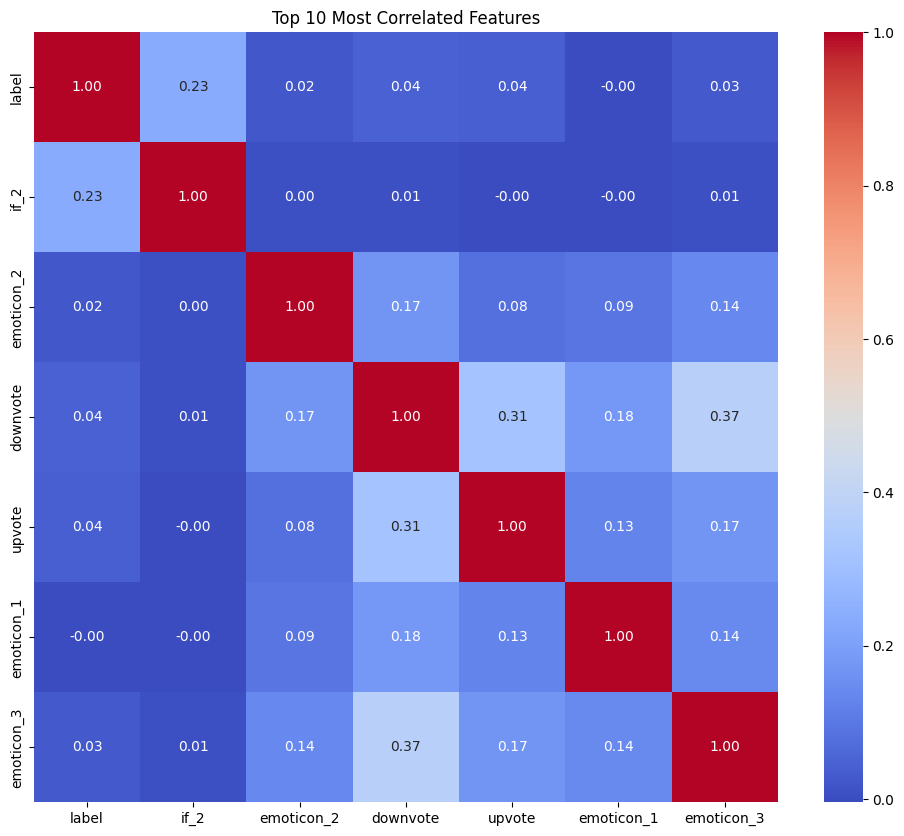

In [45]:
correlation_matrix = data.select_dtypes(include=[np.number]).corr()
top_10 = (
    correlation_matrix
    .unstack()
    .sort_values(ascending=False, key=abs)
    .drop_duplicates()
)
top_10 = top_10[top_10 < 1].head(10)
top_features = set()
for (col1, col2) in top_10.index:
    top_features.add(col1)
    top_features.add(col2)
top_features_df = data[list(top_features)]
plt.figure(figsize=(12, 10))
sns.heatmap(top_features_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Top 10 Most Correlated Features")
plt.show()

#### Since there is no feature in which there is high value of correlation between them so we cannot drop any feature

In [46]:
def detect_outliers_iqr(df):
    results = []
    
    for col in df.select_dtypes(include=np.number):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        results.append([col, len(outliers)])
    
    return pd.DataFrame(results, columns=["Feature", "Outlier_Count"]).sort_values(
        "Outlier_Count", ascending=False
    )
outliers_df = detect_outliers_iqr(data)
print(outliers_df)

      Feature  Outlier_Count
1  emoticon_1          28922
4      upvote          17304
3  emoticon_3          17165
5    downvote          15173
2  emoticon_2           8109
0     post_id           4823
7        if_2           3930
6        if_1             85
8       label              0


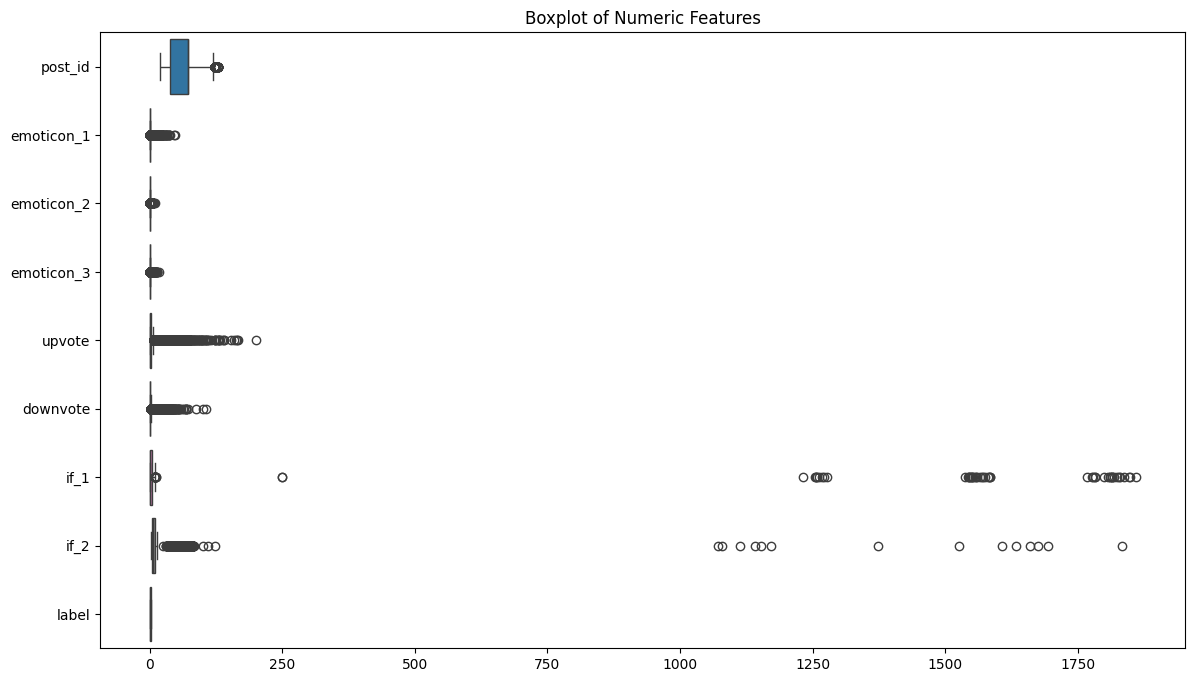

In [47]:
numeric_cols = data.select_dtypes(include='number').columns
plt.figure(figsize=(14, 8))
sns.boxplot(data=data[numeric_cols], orient='h')
plt.title("Boxplot of Numeric Features")
plt.show()

# **Data Preprocessing**

### **Feature Extraction & Feature Engineering**

In [48]:
data['created_date']=pd.to_datetime(data['created_date'])
test['created_date']=pd.to_datetime(test['created_date'])

In [49]:
data['hour'] = data['created_date'].dt.hour
data['day_of_week'] = data['created_date'].dt.dayofweek
test['hour'] = test['created_date'].dt.hour
test['day_of_week'] = test['created_date'].dt.dayofweek


In [50]:
data['engagement_score'] = data['upvote'] - data['downvote']
test['engagement_score'] = test['upvote'] - test['downvote']

In [51]:
data["disability"] = data["disability"].astype(int)
test["disability"] = test["disability"].astype(int)


In [52]:
data["gender"] = data["gender"].fillna("Missing")
data["religion"] = data["religion"].fillna("Missing")
data["race"] = data["race"].fillna("Missing")

test["gender"] = test["gender"].fillna("Missing")
test["religion"] = test["religion"].fillna("Missing")
test["race"] = test["race"].fillna("Missing")

In [53]:
print(data.shape)
print(test.shape)

(198000, 18)
(102000, 17)


In [54]:
type(data)

pandas.core.frame.DataFrame

In [55]:
import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):        
        return ""
    text = str(text)         
    text = text.lower()
    text = re.sub(r'http\S+', '', text)        
    text = re.sub(r'[^a-z0-9\s]', '', text)   
    text = re.sub(r'\s+', ' ', text).strip()  
    return text
data['clean_comment'] = data['comment'].apply(clean_text)
test['clean_comment'] = test['comment'].apply(clean_text)

In [56]:
data.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'hour', 'day_of_week',
       'engagement_score', 'clean_comment'],
      dtype='object')

In [57]:
data.drop(columns= ['created_date', 'upvote', 'downvote', 'comment'], axis=1, inplace=True, errors ='ignore')
test.drop(columns= ['created_date', 'upvote', 'downvote', 'comment'], axis=1, inplace=True, errors ='ignore')

In [58]:
print(data.shape)
print(test.shape)

(198000, 15)
(102000, 14)


In [59]:
X = data.drop('label', axis=1)
y = data['label']

In [60]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=0)

In [61]:
X_train = pd.DataFrame(X_train)
print(type(X_train))

X_test = pd.DataFrame(X_test)
print(type(X_test))
y_train = pd.DataFrame(y_train)
print(type(y_train))

y_test = pd.DataFrame(y_test)
print(type(y_test))

print(X_train.shape)
print(X_test.shape)
print(test.shape)
print(y_train.shape)
print(y_test.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(158400, 14)
(39600, 14)
(102000, 14)
(158400, 1)
(39600, 1)


In [62]:
print(X_train.shape)
print(X_test.shape)

(158400, 14)
(39600, 14)


In [63]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158400 entries, 104735 to 43567
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   post_id           158400 non-null  int64 
 1   emoticon_1        158400 non-null  int64 
 2   emoticon_2        158400 non-null  int64 
 3   emoticon_3        158400 non-null  int64 
 4   if_1              158400 non-null  int64 
 5   if_2              158400 non-null  int64 
 6   race              158400 non-null  object
 7   religion          158400 non-null  object
 8   gender            158400 non-null  object
 9   disability        158400 non-null  int64 
 10  hour              158400 non-null  int32 
 11  day_of_week       158400 non-null  int32 
 12  engagement_score  158400 non-null  int64 
 13  clean_comment     158400 non-null  object
dtypes: int32(2), int64(8), object(4)
memory usage: 16.9+ MB


# **Pipeline**

In [64]:
text_feature = ["clean_comment"]
categorical_features = ["religion", "race", "gender"]  
numeric_features = [
    "engagement_score", "disability",
    "emoticon_1", "emoticon_2", "emoticon_3",
    "if_1", "if_2", "post_id", "day_of_week", "hour"
]

In [65]:
cat_pipe=Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))
])
cat_pipe

Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [66]:
num_pipe = Pipeline([  
    ("scaler", StandardScaler())
])
num_pipe

Pipeline(steps=[('scaler', StandardScaler())])

In [67]:

text_pipe = Pipeline([
    ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        stop_words="english"
    ))
])

In [68]:

preprocessor = ColumnTransformer([
    ("text", text_pipe, text_feature),
    ("cat", cat_pipe, categorical_features),
    ("num", num_pipe, numeric_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])



In [70]:
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('flatten',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7ffb226b5e40>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=5000,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english'))]),
                                                  ['clean_comment']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['religion', 'race',
                                                   'gender']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['engagement_score',
                                                   'disability', 'emoticon_1',
                                                   'emoticon_2', 'emoticon_3',
                                                   'if_1', 'if_2', 'post_id',
                                                   'day_of_week', 'hour'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [71]:
y_pred = model_pipeline.predict(X_test)

In [72]:
print(y_pred)

[0 0 3 ... 0 0 1]


In [73]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8787878787878788
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     22807
           1       0.65      0.83      0.73      3111
           2       0.88      0.81      0.85     12572
           3       0.36      0.79      0.50      1110

    accuracy                           0.88     39600
   macro avg       0.72      0.84      0.76     39600
weighted avg       0.90      0.88      0.89     39600

Confusion Matrix:
 [[21090   395   901   421]
 [   18  2596   352   145]
 [  457   912 10238   965]
 [   14    75   145   876]]


# **Hyperparameter Tuning**

Randomised search cv

# **Final Submission**

In [74]:
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
test_predictions = model_pipeline.predict(test)
sample['label'] = test_predictions
sample.to_csv('submission.csv', index=False)
print("Fixed submission file created")

Fixed submission file created


In [75]:
sample = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
submission = pd.read_csv('submission.csv')

print("Sample shape:", sample.shape)
print("Submission shape:", submission.shape)

print("Sample columns:", sample.columns)
print("Submission columns:", submission.columns)

Sample shape: (102000, 2)
Submission shape: (102000, 2)
Sample columns: Index(['ID', 'label'], dtype='object')
Submission columns: Index(['ID', 'label'], dtype='object')
